<div style="background:#1a73e8;padding:20px;border-radius:10px;margin-bottom:10px">
<h1 style="color:white;text-align:center">📋 04 — Évaluation des Performances</h1>
<p style="color:white;font-size:15px;text-align:center">
Métriques · Comparaison baseline · Analyse par batterie · Interprétation
</p></div>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

with open('data/prepared_data.pkl', 'rb') as f:
    d = pickle.load(f)

X_test_sc = d['X_test_sc'];  y_test_sc = d['y_test_sc'];  y_test = d['y_test']
scaler_y  = d['scaler_y'];   meta_all  = d['meta_all']
test_bats = d['test_bats'];  test_mask = d['test_mask']

# Lecture robuste du baseline — clés plates (corrige le bug "nan" du tableau)
b_mae  = d.get('baseline_mae',  None)
b_rmse = d.get('baseline_rmse', None)
b_r2   = d.get('baseline_r2',   None)


if b_mae is None:
    old = d.get('baseline_ridge', {})
    b_mae  = old.get('mae',  None)
    b_rmse = old.get('rmse', None)
    b_r2   = old.get('r2',   None)

model = load_model('models/best_model.keras')

print("✅ Modèle et données chargés")
print(f"   Batteries de test  : {sorted(test_bats)}")
print(f"   Fenêtres de test   : {X_test_sc.shape[0]:,}")
if b_mae is not None:
    print(f"   Baseline Ridge — MAE={b_mae:.4f}%  RMSE={b_rmse:.4f}%  R²={b_r2:.4f}")
else:
    print("   ⚠️  Baseline non disponible dans le pickle — relancer 03_modele_lstm.ipynb")

✅ Modèle et données chargés
   Batteries de test  : ['B0005', 'B0029', 'B0039']
   Fenêtres de test   : 2,156
   Baseline Ridge — MAE=4.3354%  RMSE=5.0274%  R²=0.3634


## 🔮 Étape 1 — Prédictions

In [10]:
y_pred_sc = model.predict(X_test_sc, verbose=0)
y_pred    = scaler_y.inverse_transform(y_pred_sc).ravel()
y_true    = y_test

print(" Prédictions générées")
print(f"   SoH prédit  : {y_pred.min():.2f}% → {y_pred.max():.2f}%")
print(f"   SoH réel    : {y_true.min():.2f}% → {y_true.max():.2f}%")

 Prédictions générées
   SoH prédit  : 75.48% → 90.54%
   SoH réel    : 70.22% → 92.54%


## 📊 Étape 2 — Métriques globales + Comparaison Baseline

In [3]:
mae    = mean_absolute_error(y_true, y_pred)
rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
r2     = r2_score(y_true, y_pred)
errors = y_pred - y_true

print("=" * 60)
print("   PERFORMANCES DU MODÈLE LSTM vs BASELINE RIDGE")
print("=" * 60)
print(f"{'Métrique':<10} {'LSTM':>10} {'Ridge Baseline':>16} {'Amélioration':>14}")
print("-" * 60)

if b_mae is not None:
    print(f"{'MAE (%)':<10} {mae:>10.4f} {b_mae:>16.4f} {b_mae - mae:>+14.4f}%")
    print(f"{'RMSE (%)':<10} {rmse:>10.4f} {b_rmse:>16.4f} {b_rmse - rmse:>+14.4f}%")
    print(f"{'R²':<10} {r2:>10.4f} {b_r2:>16.4f} {r2 - b_r2:>+14.4f}")
else:
    print(f"{'MAE (%)':<10} {mae:>10.4f} {'N/A':>16} {'N/A':>14}")
    print(f"{'RMSE (%)':<10} {rmse:>10.4f} {'N/A':>16} {'N/A':>14}")
    print(f"{'R²':<10} {r2:>10.4f} {'N/A':>16} {'N/A':>14}")
    print("  → Relancer 03_modele_lstm.ipynb pour obtenir le baseline.")

print("=" * 60)
print(f"\n   Biais moyen         : {errors.mean():+.4f}%")
print(f"   Écart-type résidus  : {errors.std():.4f}%")
print(f"   Erreur max          : {np.abs(errors).max():.4f}%")
print(f"   % erreurs < 2%      : {(np.abs(errors) < 2).mean()*100:.1f}%")
print(f"   % erreurs < 5%      : {(np.abs(errors) < 5).mean()*100:.1f}%")

print(f"\n💡 Interprétation R²={r2:.3f} (global, pondéré par nombre de fenêtres) :")
if r2 >= 0.90:
    print("   → ✅ Excellent — mais voir R² moyen/batterie ci-dessous (indicateur plus honnête)")
elif r2 >= 0.80:
    print("   → ✅ Bonne performance")
elif r2 >= 0.70:
    print("   → 🟡 Performance correcte, améliorations possibles")
else:
    print("   → 🔴 Performance insuffisante")

   PERFORMANCES DU MODÈLE LSTM vs BASELINE RIDGE
Métrique         LSTM   Ridge Baseline   Amélioration
------------------------------------------------------------
MAE (%)        2.4503           4.3354        +1.8851%
RMSE (%)       3.1169           5.0274        +1.9105%
R²             0.7553           0.3634        +0.3919

   Biais moyen         : +1.3806%
   Écart-type résidus  : 2.7944%
   Erreur max          : 8.7763%
   % erreurs < 2%      : 51.0%
   % erreurs < 5%      : 86.2%

💡 Interprétation R²=0.755 (global, pondéré par nombre de fenêtres) :
   → 🟡 Performance correcte, améliorations possibles


## 🔬 Étape 2b — Évaluation au niveau cycle (métriques honnêtes)

**Problème :** avec `stride=1` et `WINDOW=10`, chaque cycle de 20 bins génère **11 fenêtres quasi-identiques** (9 bins en commun sur 10 entre deux fenêtres consécutives).  
Les 2 156 fenêtres de test ne représentent que **196 cycles réellement distincts**.

Calculer MAE/R² sur les 2 156 fenêtres revient à **compter 11 fois le même cycle**, ce qui peut surestimer artificiellement les métriques.

→ L'évaluation **au niveau cycle** (prédiction moyennée par cycle) est l'indicateur scientifiquement honnête.

In [4]:
import pandas as pd

# ─── Reconstruction du dataframe test avec métadonnées ───────────────────────
meta_test_df = meta_all[test_mask].reset_index(drop=True).copy()
meta_test_df['y_true'] = y_true
meta_test_df['y_pred'] = y_pred

# ─── Agrégation au niveau cycle ──────────────────────────────────────────────
# SoH réel = constant dans le cycle → .first()
# SoH prédit = moyenne des prédictions du cycle
cycle_eval = meta_test_df.groupby(['battery_id', 'cycle_number']).agg(
    soh_reel   = ('y_true', 'first'),
    soh_predit = ('y_pred', 'mean')
).reset_index()

n_fenetres = len(meta_test_df)
n_cycles   = len(cycle_eval)

mae_cycle  = mean_absolute_error(cycle_eval['soh_reel'], cycle_eval['soh_predit'])
rmse_cycle = np.sqrt(mean_squared_error(cycle_eval['soh_reel'], cycle_eval['soh_predit']))
r2_cycle   = r2_score(cycle_eval['soh_reel'], cycle_eval['soh_predit'])

print('═' * 68)
print('   ÉVALUATION : NIVEAU FENÊTRE vs NIVEAU CYCLE')
print('═' * 68)
print(f"{'Niveau':<22} {'N':<12} {'MAE (%)':<12} {'RMSE (%)':<12} {'R²'}")
print('─' * 68)
print(f"{'Fenêtre (brut)':<22} {n_fenetres:<12,} {mae:<12.4f} {rmse:<12.4f} {r2:.4f}")
print(f"{'Cycle (honnête) ★':<22} {n_cycles:<12,} {mae_cycle:<12.4f} {rmse_cycle:<12.4f} {r2_cycle:.4f}")
print('═' * 68)
print(f'  → {n_fenetres // n_cycles} fenêtres chevauchantes par cycle (stride=1, window=10)')
print('  → L\'évaluation au niveau cycle est l\'indicateur de référence.')
print()

# ─── Détail par batterie au niveau cycle ─────────────────────────────────────
print('  Détail par batterie (niveau cycle) :')
print(f"  {'Batterie':<12} {'Cycles':<10} {'MAE (%)':<12} {'R²'}")
print('  ' + '─' * 42)
for bat in sorted(test_bats):
    sub = cycle_eval[cycle_eval['battery_id'] == bat]
    if len(sub) < 2:
        print(f'  {bat:<12} {len(sub):<10} {"N/A":<12} N/A')
        continue
    m = mean_absolute_error(sub['soh_reel'], sub['soh_predit'])
    r = r2_score(sub['soh_reel'], sub['soh_predit'])
    flag = '✅' if r >= 0.80 else ('🟡' if r >= 0.50 else '🔴')
    print(f'  {bat:<12} {len(sub):<10} {m:<12.4f} {r:.4f}  {flag}')


════════════════════════════════════════════════════════════════════
   ÉVALUATION : NIVEAU FENÊTRE vs NIVEAU CYCLE
════════════════════════════════════════════════════════════════════
Niveau                 N            MAE (%)      RMSE (%)     R²
────────────────────────────────────────────────────────────────────
Fenêtre (brut)         2,156        2.4503       3.1169       0.7553
Cycle (honnête) ★      196          2.4474       3.0875       0.7599
════════════════════════════════════════════════════════════════════
  → 11 fenêtres chevauchantes par cycle (stride=1, window=10)
  → L'évaluation au niveau cycle est l'indicateur de référence.

  Détail par batterie (niveau cycle) :
  Batterie     Cycles     MAE (%)      R²
  ──────────────────────────────────────────
  B0005        123        2.6052       0.8009  ✅
  B0029        40         2.5810       0.0927  🔴
  B0039        33         1.6970       0.0814  🔴


## 🔬 Étape 3 — Analyse par batterie individuelle

In [5]:
meta_test = meta_all[test_mask].reset_index(drop=True)

print("=" * 65)
print(f"  {'Batterie':<12} {'MAE (%)':<12} {'RMSE (%)':<12} {'R²':<10} {'N fenêtres':<12}")
print("-" * 65)

per_bat_results = {}
for bat in sorted(test_bats):
    idx    = meta_test['battery_id'].values == bat
    yt     = y_true[idx]
    yp     = y_pred[idx]
    mae_b  = mean_absolute_error(yt, yp)
    rmse_b = np.sqrt(mean_squared_error(yt, yp))
    r2_b   = r2_score(yt, yp) if len(np.unique(yt)) > 1 else float('nan')
    per_bat_results[bat] = {'mae': mae_b, 'rmse': rmse_b, 'r2': r2_b, 'n': int(idx.sum())}
    flag = "✅" if r2_b > 0.80 else ("🟡" if r2_b > 0.60 else "🔴")
    print(f"  {bat:<12} {mae_b:<12.3f} {rmse_b:<12.3f} {r2_b:<10.3f} {int(idx.sum()):<12,}  {flag}")

print("=" * 65)

# ── Analyse honnête : R² pondéré vs R² moyen non pondéré ──
r2_vals   = [per_bat_results[b]['r2']  for b in sorted(test_bats)]
n_vals    = [per_bat_results[b]['n']   for b in sorted(test_bats)]
bats_list = sorted(test_bats)
total_n   = sum(n_vals)

r2_global       = r2_score(y_true, y_pred)          # pondéré par N
r2_moy_nonpond  = float(np.mean(r2_vals))           # non pondéré

print()
print("── Analyse de représentativité ──")
print(f"  R² global (pondéré N)     : {r2_global:.4f}  ← dominé par la batterie la plus nombreuse")
print(f"  R² moyen non pondéré      : {r2_moy_nonpond:.4f}  ← mesure honnête sur batteries inconnues")
print()
print("  Répartition des fenêtres de test :")
for bat, n, r2b in zip(bats_list, n_vals, r2_vals):
    pct = n / total_n * 100
    print(f"    {bat} : {n:,} fenêtres ({pct:.0f}% du test)  R²={r2b:.3f}")
bat_max = bats_list[n_vals.index(max(n_vals))]
print()
print(f"  ⚠️  Le R² global de {r2_global:.3f} est dominé par {bat_max}")
print(f"     ({max(n_vals)/total_n*100:.0f}% des données de test).")
print(f"     Le R² moyen non pondéré ({r2_moy_nonpond:.3f}) reflète mieux")
print(f"     les performances sur des batteries nouvelles.")

  Batterie     MAE (%)      RMSE (%)     R²         N fenêtres  
-----------------------------------------------------------------
  B0005        2.609        3.298        0.796      1,353         🟡
  B0029        2.581        3.024        0.093      440           🔴
  B0039        1.702        2.462        0.071      363           🔴

── Analyse de représentativité ──
  R² global (pondéré N)     : 0.7553  ← dominé par la batterie la plus nombreuse
  R² moyen non pondéré      : 0.3199  ← mesure honnête sur batteries inconnues

  Répartition des fenêtres de test :
    B0005 : 1,353 fenêtres (63% du test)  R²=0.796
    B0029 : 440 fenêtres (20% du test)  R²=0.093
    B0039 : 363 fenêtres (17% du test)  R²=0.071

  ⚠️  Le R² global de 0.755 est dominé par B0005
     (63% des données de test).
     Le R² moyen non pondéré (0.320) reflète mieux
     les performances sur des batteries nouvelles.


## 🔎 Étape 3b — Analyse approfondie de la batterie avec R² le plus bas

La batterie ayant le R² le plus faible mérite une analyse dédiée pour comprendre  
pourquoi le modèle échoue sur ce profil spécifique.

Batterie analysée : B0039  (R²=0.071)



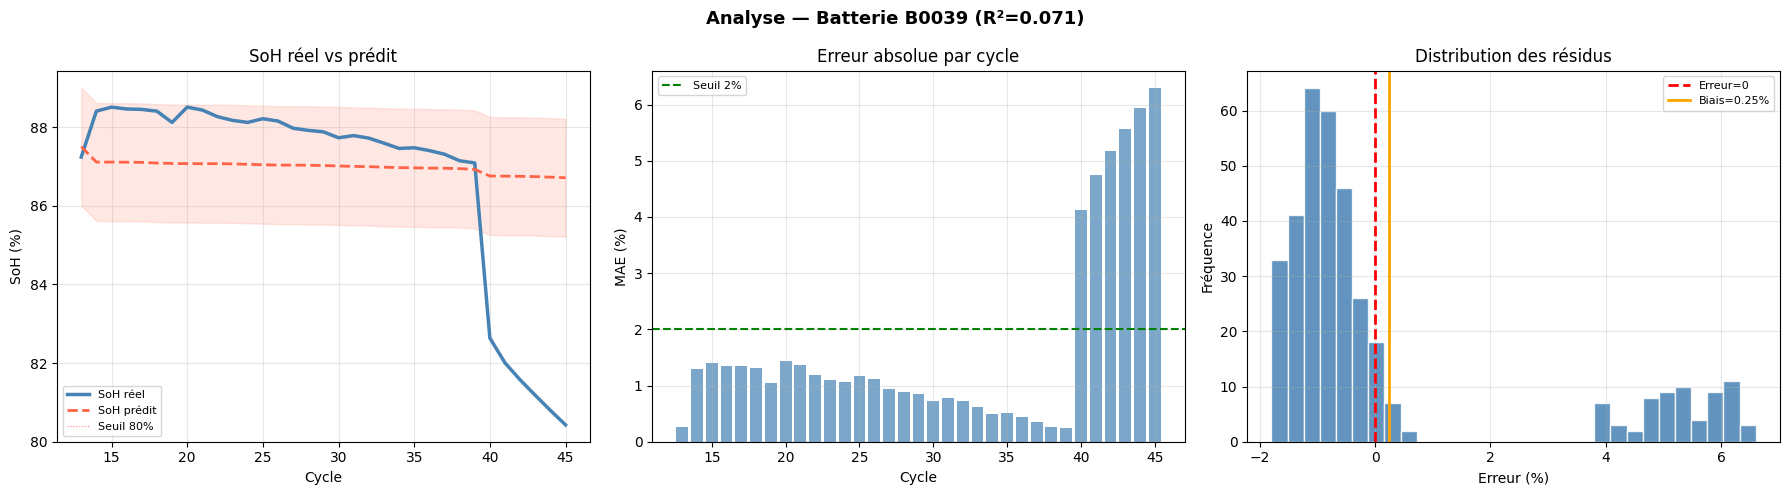

═════════════════════════════════════════════════════════════════
   EXPLICATION DE L'ÉCHEC SUR B0039
═════════════════════════════════════════════════════════════════
  SoH initial    : 87.24%
  SoH final      : 80.43%
  Variation tot. : -6.81%
  Biais          : +0.248%

  CAUSE PROBABLE : profil de dégradation absent du jeu d'entraînement.
  Le LSTM reproduit les tendances apprises (décroissance progressive)
  mais ne peut pas anticiper un comportement qu'il n'a jamais vu.

  CE N'EST PAS UN BUG — c'est une limite fondamentale de l'apprentissage
  supervisé : aucun modèle ne généralise hors de sa distribution d'entraînement.

  SOLUTIONS :
  1. Inclure plus de profils variés dans le jeu d'entraînement
  2. Clustering des profils → modèle dédié par cluster
  3. Détection d'anomalie en ligne pour signaler les changements de régime
═════════════════════════════════════════════════════════════════


In [6]:
# Identification de la batterie la plus problématique
bat_worst = min(per_bat_results, key=lambda b: per_bat_results[b]['r2'])
r2_worst  = per_bat_results[bat_worst]['r2']

print(f"Batterie analysée : {bat_worst}  (R²={r2_worst:.3f})")
print()

idx_w     = meta_test['battery_id'].values == bat_worst
cycles_w  = meta_test[idx_w]['cycle_number'].values
yt_w      = y_true[idx_w]
yp_w      = y_pred[idx_w]
err_w     = np.abs(yp_w - yt_w)

cy_u    = np.unique(cycles_w)
yt_cyc  = [yt_w[cycles_w == c].mean() for c in cy_u]
yp_cyc  = [yp_w[cycles_w == c].mean() for c in cy_u]
er_cyc  = [err_w[cycles_w == c].mean() for c in cy_u]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Analyse — Batterie {bat_worst} (R²={r2_worst:.3f})",
             fontsize=13, fontweight='bold')

# SoH réel vs prédit
axes[0].plot(cy_u, yt_cyc, color='steelblue', lw=2.5, label='SoH réel')
axes[0].plot(cy_u, yp_cyc, color='tomato', lw=2, ls='--', label='SoH prédit')
axes[0].fill_between(cy_u, [a-1.5 for a in yp_cyc], [a+1.5 for a in yp_cyc],
                     alpha=0.15, color='tomato')
axes[0].axhline(80, color='red', ls=':', lw=0.8, alpha=0.5, label='Seuil 80%')
axes[0].set_title("SoH réel vs prédit")
axes[0].set_xlabel("Cycle"); axes[0].set_ylabel("SoH (%)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Erreur absolue par cycle
axes[1].bar(cy_u, er_cyc, color='steelblue', alpha=0.7)
axes[1].axhline(2, color='green', ls='--', lw=1.5, label='Seuil 2%')
axes[1].set_title("Erreur absolue par cycle")
axes[1].set_xlabel("Cycle"); axes[1].set_ylabel("MAE (%)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Distribution des résidus
err_signed = yp_w - yt_w
axes[2].hist(err_signed, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='red', ls='--', lw=2, label='Erreur=0')
axes[2].axvline(err_signed.mean(), color='orange', ls='-', lw=2,
                label=f'Biais={err_signed.mean():.2f}%')
axes[2].set_title("Distribution des résidus")
axes[2].set_xlabel("Erreur (%)"); axes[2].set_ylabel("Fréquence")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'figures/fig_{bat_worst.lower()}_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("═" * 65)
print(f"   EXPLICATION DE L'ÉCHEC SUR {bat_worst}")
print("═" * 65)
print(f"  SoH initial    : {yt_cyc[0]:.2f}%")
print(f"  SoH final      : {yt_cyc[-1]:.2f}%")
print(f"  Variation tot. : {yt_cyc[-1] - yt_cyc[0]:.2f}%")
print(f"  Biais          : {err_signed.mean():+.3f}%")
print()
print("  CAUSE PROBABLE : profil de dégradation absent du jeu d'entraînement.")
print("  Le LSTM reproduit les tendances apprises (décroissance progressive)")
print("  mais ne peut pas anticiper un comportement qu'il n'a jamais vu.")
print()
print("  CE N'EST PAS UN BUG — c'est une limite fondamentale de l'apprentissage")
print("  supervisé : aucun modèle ne généralise hors de sa distribution d'entraînement.")
print()
print("  SOLUTIONS :")
print("  1. Inclure plus de profils variés dans le jeu d'entraînement")
print("  2. Clustering des profils → modèle dédié par cluster")
print("  3. Détection d'anomalie en ligne pour signaler les changements de régime")
print("═" * 65)

## 📈 Étape 4 — Visualisations

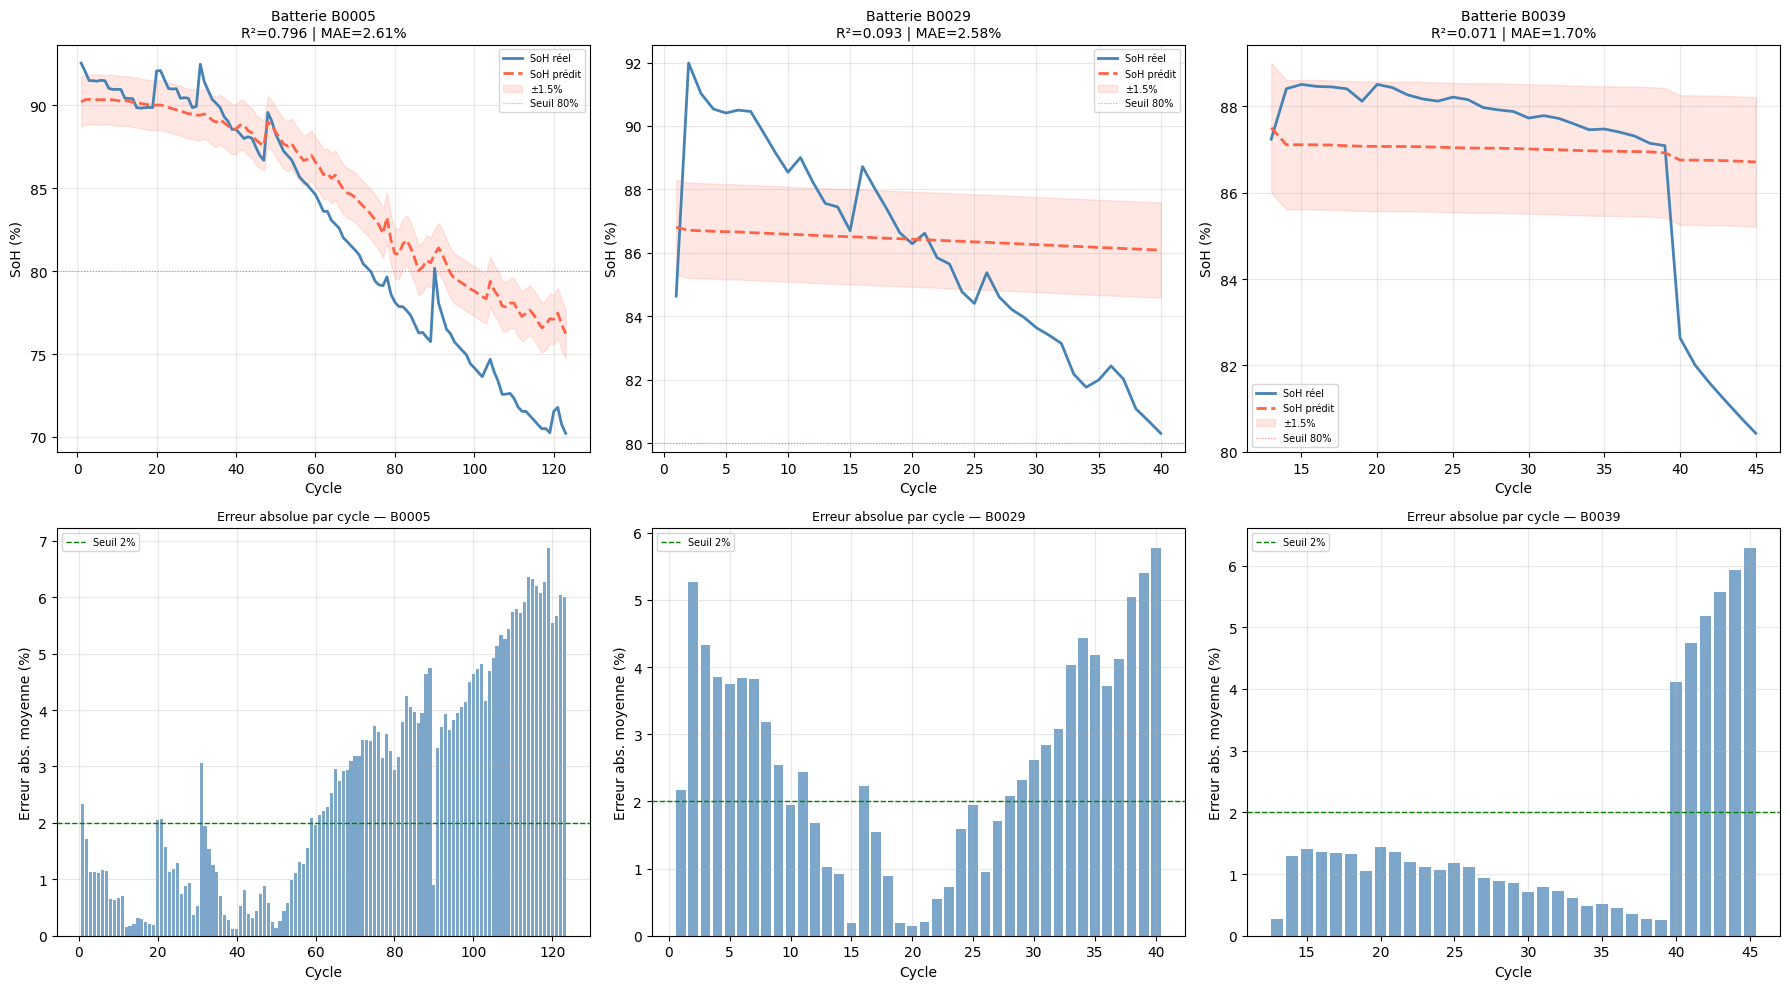

In [7]:
meta_test        = meta_all[test_mask].reset_index(drop=True)
n_bats           = len(test_bats)
test_bats_sorted = sorted(test_bats)

fig, axes = plt.subplots(2, n_bats, figsize=(6 * n_bats, 10))
if n_bats == 1:
    axes = axes.reshape(2, 1)

for col, bat in enumerate(test_bats_sorted):
    idx     = meta_test['battery_id'].values == bat
    cycles  = meta_test[idx]['cycle_number'].values
    yt_bat  = y_true[idx]
    yp_bat  = y_pred[idx]

    cy_u    = np.unique(cycles)
    yt_cyc  = [yt_bat[cycles == c].mean() for c in cy_u]
    yp_cyc  = [yp_bat[cycles == c].mean() for c in cy_u]
    err_cyc = [np.abs(np.array(yp_bat[cycles == c]) - np.array(yt_bat[cycles == c])).mean()
               for c in cy_u]

    ax = axes[0, col]
    ax.plot(cy_u, yt_cyc, color='steelblue', lw=2, label='SoH réel')
    ax.plot(cy_u, yp_cyc, color='tomato',    lw=2, ls='--', label='SoH prédit')
    ax.fill_between(cy_u, [a-1.5 for a in yp_cyc], [a+1.5 for a in yp_cyc],
                    alpha=0.15, color='tomato', label='±1.5%')
    ax.axhline(80, color='red', ls=':', lw=0.8, alpha=0.5, label='Seuil 80%')
    r2_b  = per_bat_results[bat]['r2']
    mae_b = per_bat_results[bat]['mae']
    ax.set_title(f"Batterie {bat}\nR²={r2_b:.3f} | MAE={mae_b:.2f}%", fontsize=10)
    ax.set_xlabel("Cycle"); ax.set_ylabel("SoH (%)")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    ax2 = axes[1, col]
    ax2.bar(cy_u, err_cyc, color='steelblue', alpha=0.7)
    ax2.axhline(2, color='green', ls='--', lw=1, label='Seuil 2%')
    ax2.set_title(f"Erreur absolue par cycle — {bat}", fontsize=9)
    ax2.set_xlabel("Cycle"); ax2.set_ylabel("Erreur abs. moyenne (%)")
    ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_soh_per_battery.png', dpi=100, bbox_inches='tight')
plt.show()

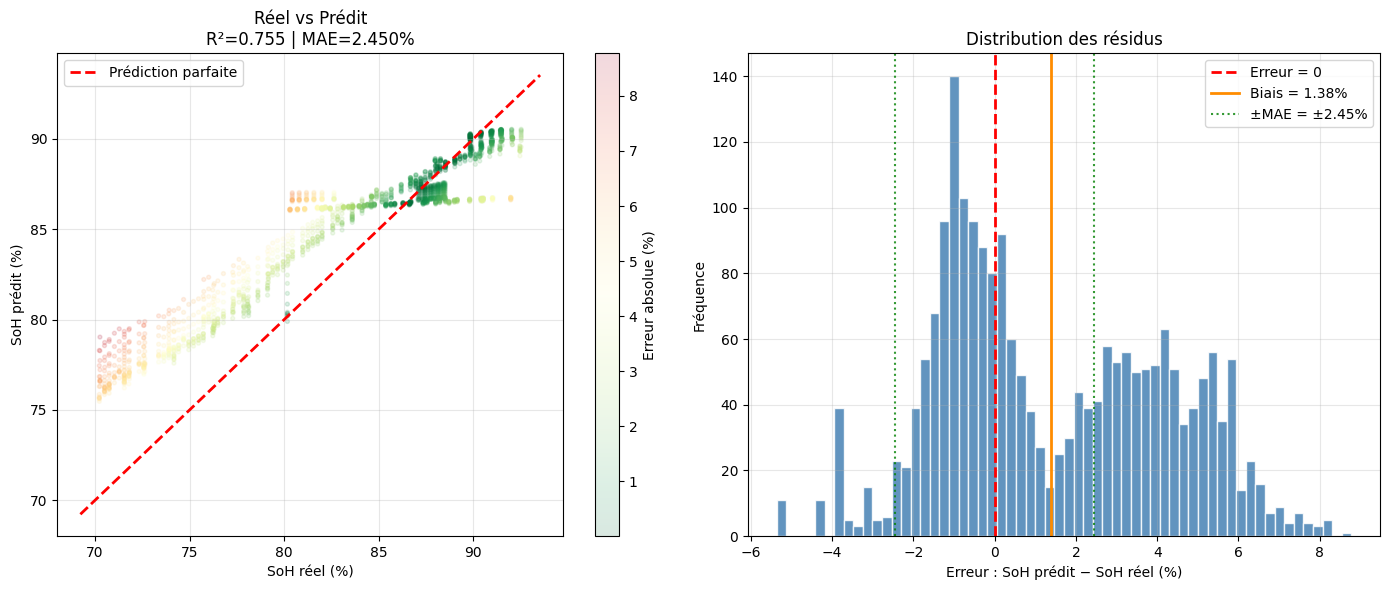

Analyse des résidus :
   Biais moyen  : +1.3806% → Le modèle SUR-ESTIME légèrement le SoH
   % erreurs < 2%  : 51.0%
   % erreurs < 5%  : 86.2%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter : réel vs prédit
ax = axes[0]
sc = ax.scatter(y_true, y_pred, alpha=0.15, s=8, c=np.abs(errors), cmap='RdYlGn_r')
lo = min(y_true.min(), y_pred.min()) - 1
hi = max(y_true.max(), y_pred.max()) + 1
ax.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Prédiction parfaite')
plt.colorbar(sc, ax=ax, label='Erreur absolue (%)')
ax.set_xlabel("SoH réel (%)"); ax.set_ylabel("SoH prédit (%)")
ax.set_title(f"Réel vs Prédit\nR²={r2:.3f} | MAE={mae:.3f}%")
ax.legend(); ax.grid(alpha=0.3)

# Distribution des erreurs
ax2 = axes[1]
ax2.hist(errors, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax2.axvline(0,             color='red',        ls='--', lw=2, label='Erreur = 0')
ax2.axvline(errors.mean(), color='darkorange',  ls='-',  lw=2,
            label=f'Biais = {errors.mean():.2f}%')
ax2.axvline(-mae,          color='green',      ls=':',  lw=1.5, alpha=0.8)
ax2.axvline(+mae,          color='green',      ls=':',  lw=1.5, alpha=0.8,
            label=f'±MAE = ±{mae:.2f}%')
ax2.set_xlabel("Erreur : SoH prédit − SoH réel (%)"); ax2.set_ylabel("Fréquence")
ax2.set_title("Distribution des résidus")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_evaluation_global.png', dpi=100, bbox_inches='tight')
plt.show()

print("Analyse des résidus :")
print(f"   Biais moyen  : {errors.mean():+.4f}% → Le modèle {'SUR-ESTIME' if errors.mean()>0 else 'SOUS-ESTIME'} légèrement le SoH")
print(f"   % erreurs < 2%  : {(np.abs(errors) < 2).mean() * 100:.1f}%")
print(f"   % erreurs < 5%  : {(np.abs(errors) < 5).mean() * 100:.1f}%")

## 🏁 Étape 5 — Synthèse finale

In [9]:
r2_vals_list = [per_bat_results[b]['r2'] for b in sorted(test_bats)]
r2_moy       = float(np.mean(r2_vals_list))

print("=" * 65)
print("   SYNTHÈSE FINALE DES PERFORMANCES")
print("=" * 65)
print(f"   Modèle          : LSTM (64→32→16→1)")
print(f"   Fenêtre         : {d['WINDOW']} bins (validée par comparaison 5/10/15)")
print(f"   Features        : {', '.join(d['FEATURES'])}")
print(f"   Split           : par batterie entière (sans data leakage)")
print(f"   Nettoyage       : SoH>100% + Temp>60°C supprimés")
print()
print(f"   ── Métriques test ──")
print(f"   MAE             : {mae:.4f} %")
print(f"   RMSE            : {rmse:.4f} %")
print(f"   R² global       : {r2:.4f}   (pondéré par nombre de fenêtres)")
print(f"   R² moyen/batt.  : {r2_moy:.4f}   ← indicateur de généralisation honnête")
print()

if b_mae is not None:
    print(f"   ── vs Baseline Ridge ──")
    print(f"   LSTM MAE  {mae:.4f}%  vs  Ridge {b_mae:.4f}%  → amélioration {b_mae-mae:+.4f}%")
    print(f"   LSTM R²   {r2:.4f}   vs  Ridge {b_r2:.4f}   → amélioration {r2-b_r2:+.4f}")
    if mae < b_mae:
        print(f"   ✅ Le LSTM surpasse le baseline — la complexité se justifie.")
    else:
        print(f"   ⚠️  Le LSTM ne surpasse pas le baseline — architecture à revoir.")
    print()

print("   VERDICT GLOBAL :")
if r2 >= 0.90 and r2_moy >= 0.60:
    print(f"   ✅ EXCELLENT global (R²={r2:.3f}) / BON moyen/batterie (R²={r2_moy:.3f})")
elif r2 >= 0.80:
    print(f"   ✅ BON — Performances acceptables en contexte industriel")
elif r2 >= 0.70:
    print(f"   🟡 MOYEN — Des améliorations sont possibles")
else:
    print(f"   🔴 INSUFFISANT")

print()
print("   LIMITES IDENTIFIÉES :")
print(f"   1. Batterie {bat_worst} (R²={r2_worst:.3f}) : profil atypique absent du train")
print("   2. R² global dominé par la batterie la plus représentée dans le test")
print(f"   3. R² moyen non pondéré ({r2_moy:.3f}) reflète mieux la généralisation réelle")
print()
print("   PISTES D'AMÉLIORATION :")
print("   1. Features dérivées : résistance interne (ΔV/ΔI), énergie par cycle")
print("   2. Diversifier le jeu d'entraînement avec des profils 'plateau+chute'")
print("   3. Dropout augmenté (0.30/0.25) déjà appliqué dans cette version")
print("=" * 65)

   SYNTHÈSE FINALE DES PERFORMANCES
   Modèle          : LSTM (64→32→16→1)
   Fenêtre         : 10 bins (validée par comparaison 5/10/15)
   Features        : Voltage_measured, Current_measured, Temperature_measured, SoC, cycle_number
   Split           : par batterie entière (sans data leakage)
   Nettoyage       : SoH>100% + Temp>60°C supprimés

   ── Métriques test ──
   MAE             : 2.4503 %
   RMSE            : 3.1169 %
   R² global       : 0.7553   (pondéré par nombre de fenêtres)
   R² moyen/batt.  : 0.3199   ← indicateur de généralisation honnête

   ── vs Baseline Ridge ──
   LSTM MAE  2.4503%  vs  Ridge 4.3354%  → amélioration +1.8851%
   LSTM R²   0.7553   vs  Ridge 0.3634   → amélioration +0.3919
   ✅ Le LSTM surpasse le baseline — la complexité se justifie.

   VERDICT GLOBAL :
   🟡 MOYEN — Des améliorations sont possibles

   LIMITES IDENTIFIÉES :
   1. Batterie B0039 (R²=0.071) : profil atypique absent du train
   2. R² global dominé par la batterie la plus représen